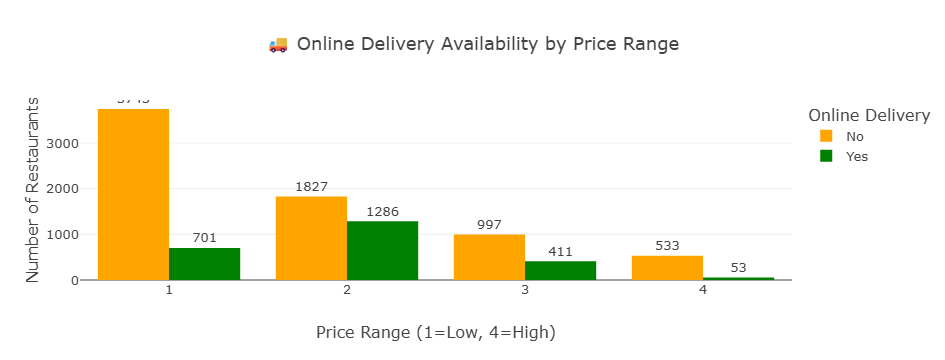

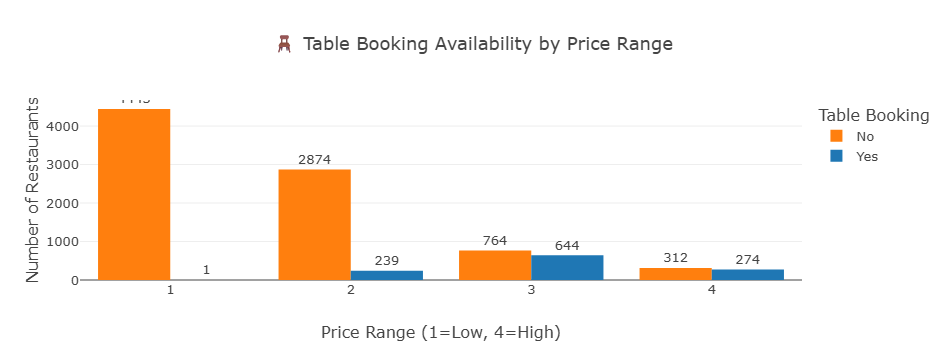

📋 Combined Availability Matrix:

Has Online delivery    No        Yes     
Has Table booking      No  Yes    No  Yes
Price range                              
1                    3743    0   700    1
2                    1711  116  1163  123
3                     624  373   140  271
4                     299  234    13   40


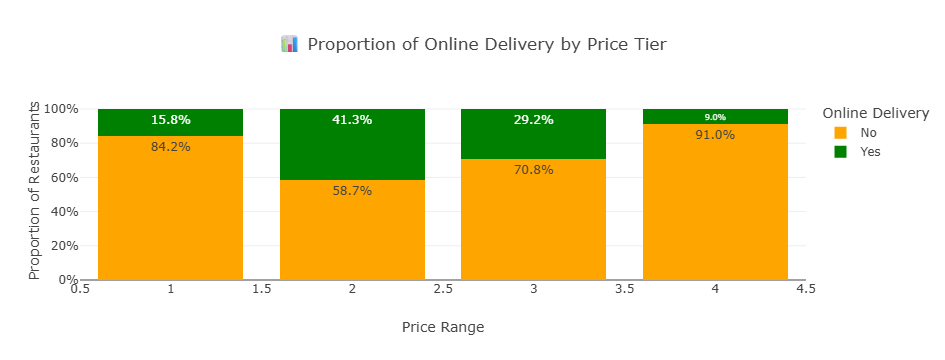

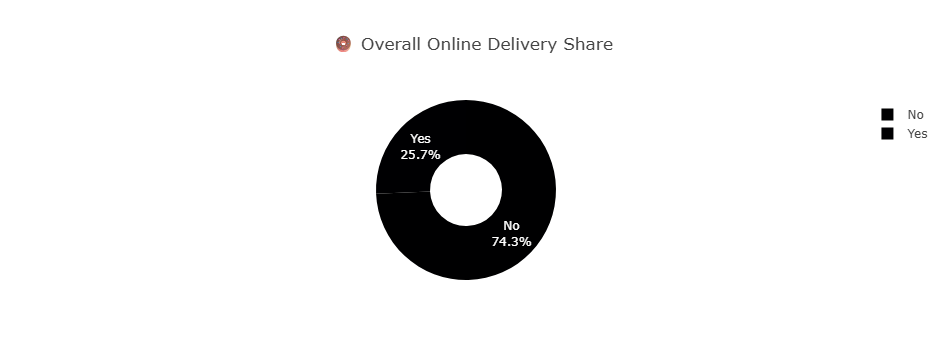

In [13]:
# 📦 Import Required Libraries
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# 📥 Load Dataset
df = pd.read_csv(r"C:\Users\acer\Downloads\Data Analysis Internship__Dataset__Cognifyz Technologies.csv")

# --------------------------------------------------------------------------------
# 🧹 DATA PREP
# --------------------------------------------------------------------------------
# Select only relevant columns and drop missing values
service_df = df[['Restaurant Name', 'Price range', 'Has Online delivery', 'Has Table booking']].dropna()

# Keep only valid Yes/No entries
service_df = service_df[
    (service_df['Has Online delivery'].isin(['Yes', 'No'])) &
    (service_df['Has Table booking'].isin(['Yes', 'No']))
]

# --------------------------------------------------------------------------------
# 📊 ANALYSIS 1: Online Delivery vs Price Range
# --------------------------------------------------------------------------------
delivery_counts = (
    service_df.groupby(['Price range', 'Has Online delivery'])
    .size()
    .reset_index(name='Count')
)

fig1 = px.bar(
    delivery_counts,
    x='Price range',
    y='Count',
    color='Has Online delivery',
    barmode='group',
    text='Count',
    title='🚚 Online Delivery Availability by Price Range',
    color_discrete_map={'Yes': 'green', 'No': 'orange'}
)
fig1.update_layout(
    xaxis_title='Price Range (1=Low, 4=High)',
    yaxis_title='Number of Restaurants',
    legend_title='Online Delivery',
    font=dict(size=13),
    plot_bgcolor='white'
)
fig1.update_traces(textposition='outside')
fig1.show()

# --------------------------------------------------------------------------------
# 📊 ANALYSIS 2: Table Booking vs Price Range
# --------------------------------------------------------------------------------
booking_counts = (
    service_df.groupby(['Price range', 'Has Table booking'])
    .size()
    .reset_index(name='Count')
)

fig2 = px.bar(
    booking_counts,
    x='Price range',
    y='Count',
    color='Has Table booking',
    barmode='group',
    text='Count',
    title='🪑 Table Booking Availability by Price Range',
    color_discrete_map={'Yes': '#1f77b4', 'No': '#ff7f0e'}
)
fig2.update_layout(
    xaxis_title='Price Range (1=Low, 4=High)',
    yaxis_title='Number of Restaurants',
    legend_title='Table Booking',
    font=dict(size=13),
    plot_bgcolor='white'
)
fig2.update_traces(textposition='outside')
fig2.show()

# --------------------------------------------------------------------------------
# 📋 BONUS: Combined Delivery + Booking Matrix
# --------------------------------------------------------------------------------
availability_matrix = pd.pivot_table(
    service_df,
    values='Restaurant Name',
    index='Price range',
    columns=['Has Online delivery', 'Has Table booking'],
    aggfunc='count',
    fill_value=0
)

print("📋 Combined Availability Matrix:\n")
print(availability_matrix)

# --------------------------------------------------------------------------------
# 📊 BONUS: Stacked % Proportions of Delivery by Price Range
# --------------------------------------------------------------------------------
delivery_prop = delivery_counts.copy()
delivery_prop['Proportion'] = delivery_prop.groupby('Price range')['Count'].transform(lambda x: x / x.sum())

fig3 = px.bar(
    delivery_prop,
    x='Price range',
    y='Proportion',
    color='Has Online delivery',
    barmode='stack',
    text='Proportion',
    title='📊 Proportion of Online Delivery by Price Tier',
    color_discrete_map={'Yes': 'green', 'No': 'orange'}
)
fig3.update_traces(texttemplate='%{text:.1%}', textposition='inside')
fig3.update_layout(
    yaxis_tickformat='.0%',
    xaxis_title='Price Range',
    yaxis_title='Proportion of Restaurants',
    legend_title='Online Delivery',
    plot_bgcolor='white'
)
fig3.show()

# --------------------------------------------------------------------------------
# 🧁 BONUS INSIGHT CHART: Donut for Total Online Delivery Share
# --------------------------------------------------------------------------------
total_delivery = service_df['Has Online delivery'].value_counts().reset_index()
total_delivery.columns = ['Online Delivery', 'Count']

fig4 = px.pie(
    total_delivery,
    names='Online Delivery',
    values='Count',
    title='🍩 Overall Online Delivery Share',
    hole=0.4,
    color_discrete_map={'Yes': 'green', 'No': 'red'}
)
fig4.update_traces(textinfo='percent+label')
fig4.show()
